### Model Interpretation with SHAP

## 1. Objective

This notebook uses SHAP (SHapley Additive exPlanations) to interpret the XGBoost model trained in the previous notebook. We aim to:

- Understand which features most influence churn predictions
- Visualize how feature values affect model output
- Explain individual predictions for specific customers
- Build trust and transparency into the model


2. Load Model & Data

In [8]:
import pandas as pd
import joblib
import shap
import xgboost as xgb

# Load data
X = pd.read_csv("../data/processed/telco_final_preprocessed.csv")
y = X.pop("Churn")

# Load trained model
model = joblib.load("../models/xgb_model.pkl")


3. SHAP Setup

In [9]:
# Initialize SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Enable JS visualizations
shap.initjs()


4. Global Interpretability — Feature Importance

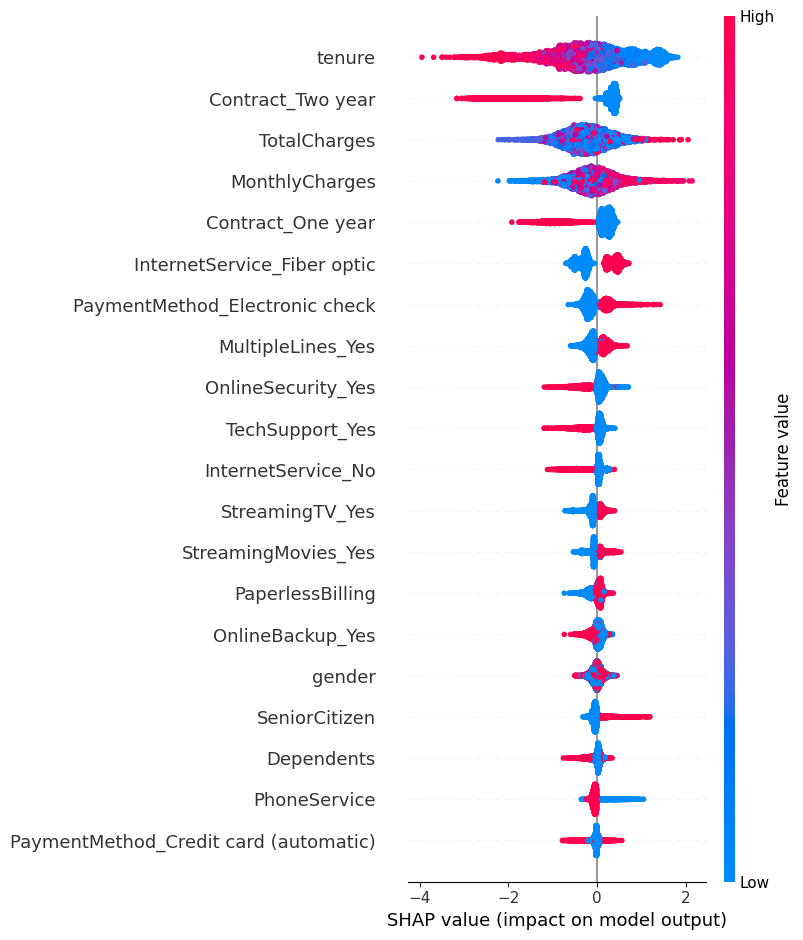

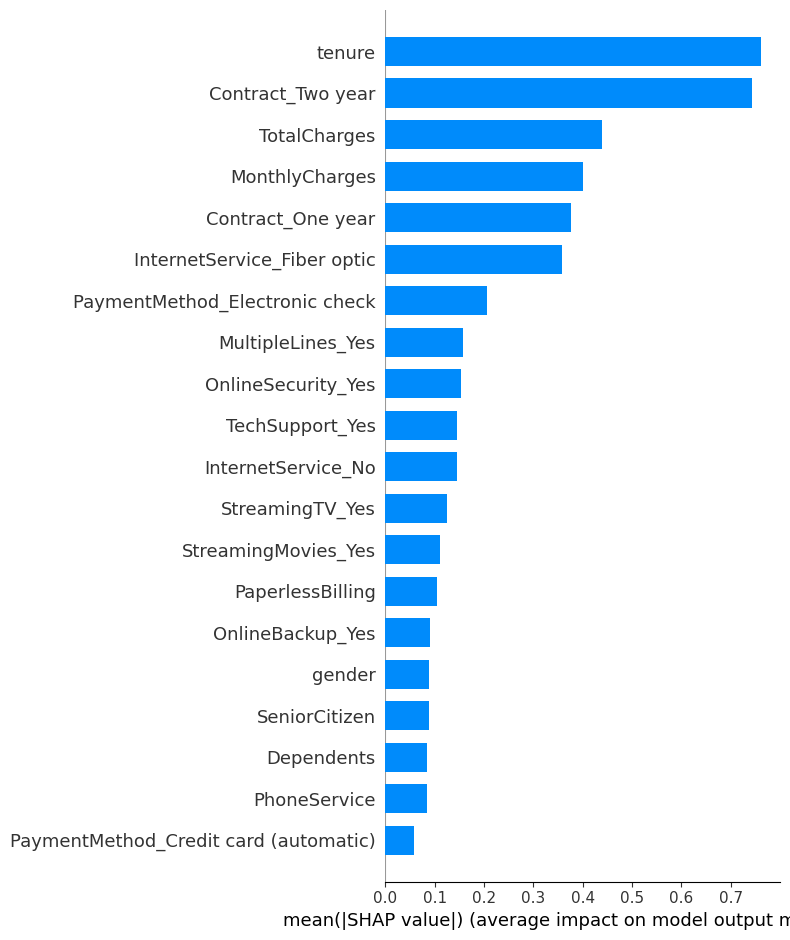

In [10]:
# Summary plot (beeswarm)
shap.summary_plot(shap_values, X)

# Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X, plot_type="bar")


 

- Features like `Contract_Two year`, `tenure`, and `MonthlyCharges` have the highest impact.
- Red dots = high feature values; blue dots = low values.
- Directionality matters: e.g., high `MonthlyCharges` → higher churn risk.


5. Local Interpretability — Individual Prediction

In [11]:
# Choose a sample customer
idx = 42
shap.plots.force(shap_values[idx])



This force plot shows how each feature pushed the prediction toward churn or retention for a specific customer. Red arrows push toward churn (1), blue toward no churn (0). You can use this to explain decisions to stakeholders or customers.


6. Feature Impact Summary — Waterfall Plot

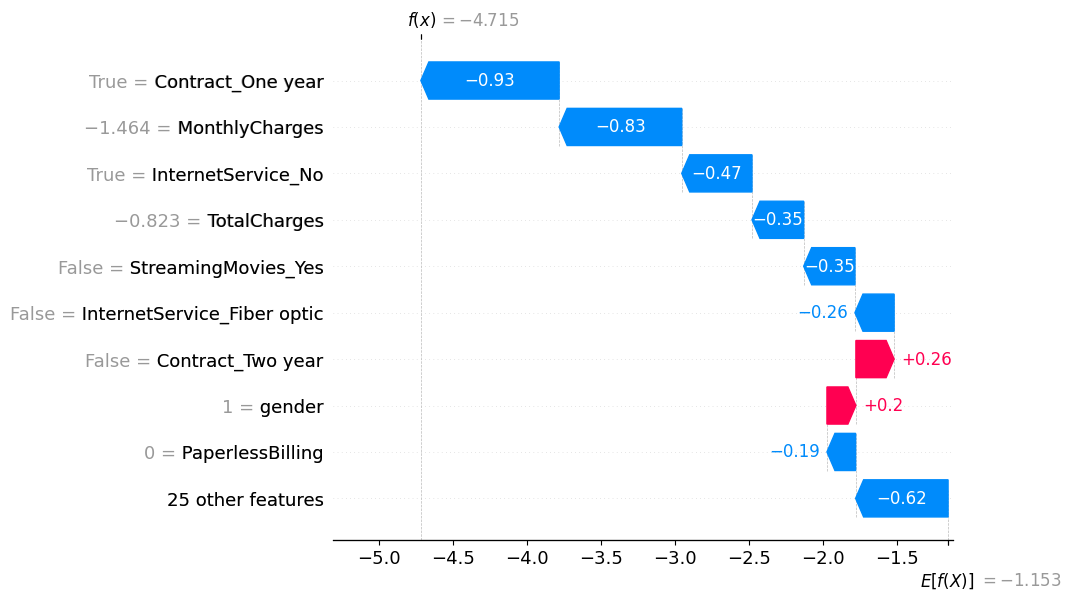

In [12]:
shap.plots.waterfall(shap_values[idx])



The waterfall plot breaks down the prediction step-by-step. Starting from the base value (average prediction), each feature adds or subtracts from the score. This is ideal for debugging and understanding edge cases.


7. Save Insights 

In [13]:
# Save SHAP values for future use
joblib.dump(shap_values, "../models/xgb_shap_values.pkl")


['../models/xgb_shap_values.pkl']

## Summary

- SHAP revealed which features drive churn predictions globally and locally.
- `Contract`, `tenure`, and `MonthlyCharges` are key influencers.
- Visualizations like force and waterfall plots help explain individual decisions.
- These insights will guide deployment and business strategy.

Next Notebook 👉 `06_deployment.ipynb`: Build a FastAPI endpoint for real-time churn prediction.
